# Импорт библиотек

In [ ]:
import kagglehub
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import albumentations as albu
import yaml
import random
import time
import pickle
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csr_matrix, issparse
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## ФИКСАЦИЯ СЛУЧАЙНЫХ СЕЙДОВ

In [2]:

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
set_seeds(42)

# НАСТРОЙКИ ДЛЯ 224x224 

In [3]:
# ==================== НАСТРОЙКИ ДЛЯ 224x224 ====================
INFER_HEIGHT = 224
INFER_WIDTH = 224
BATCH_SIZE = 32  # Для 8-12 GB VRAM. Если памяти мало - поставьте 16
LEARNING_RATE_PHASE1 = 0.001
LEARNING_RATE_PHASE2 = 0.0005

## АУГМЕНТАЦИЯ 

In [4]:

def get_augmentation():
    train_transform = [
        albu.HorizontalFlip(p=0.5),
        albu.VerticalFlip(p=0.25),
        albu.ShiftScaleRotate(
            shift_limit=0.2, 
            scale_limit=0.2, 
            rotate_limit=30, 
            p=0.7
        ),
        albu.Resize(INFER_HEIGHT, INFER_WIDTH),
        albu.OneOf([
            albu.RandomBrightnessContrast(
                brightness_limit=0.3, 
                contrast_limit=0.3, 
                p=0.8
            ),
            albu.HueSaturationValue(
                hue_shift_limit=20, 
                sat_shift_limit=30, 
                val_shift_limit=20, 
                p=0.8
            ),
        ], p=0.9),
        albu.OneOf([
            albu.GaussNoise(var_limit=(10, 50), p=0.5),
            albu.Blur(blur_limit=3, p=0.3),
        ], p=0.5),
        albu.CoarseDropout(
            max_holes=6, 
            max_height=16, 
            max_width=16, 
            fill_value=0, 
            p=0.3
        ),
    ]
    return albu.Compose(train_transform)

def get_val_augmentation():
    return albu.Compose([albu.Resize(INFER_HEIGHT, INFER_WIDTH)])

# ГЕНЕРАТОР

In [8]:

class DataGenerator(Sequence):
    def __init__(self, images, labels, batch_size=32, augment=False):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.transform = get_augmentation() if augment else get_val_augmentation()
    
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_images = self.images[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        augmented_images = []
        for img in batch_images:
            augmented = self.transform(image=img)
            augmented_images.append(augmented['image'])
        
        return np.array(augmented_images, dtype=np.float32), batch_labels
    
    def on_epoch_end(self):
        if self.augment:
            indices = np.arange(len(self.images))
            np.random.shuffle(indices)
            self.images = self.images[indices]
            self.labels = self.labels[indices]

# ЗАГРУЗКА ДАННЫХ

In [9]:

def load_data(data_path):
    images, labels = [], []
    
    yaml_path = os.path.join(data_path, 'car', 'data.yaml')
    try:
        with open(yaml_path, 'r') as f:
            class_names = yaml.safe_load(f).get('names', [])
        print(f"Классы: {class_names}")
    except:
        class_names = []
    
    for split in ['train', 'test', 'valid']:
        split_path = os.path.join(data_path, 'car', split)
        img_dir = os.path.join(split_path, 'images')
        lbl_dir = os.path.join(split_path, 'labels')
        
        if not os.path.exists(img_dir):
            continue
        
        print(f"\nЗагрузка {split}...")
        
        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm')):
                continue
                
            img_path = os.path.join(img_dir, img_file)
            label_file = img_file.rsplit('.', 1)[0] + '.txt'
            label_path = os.path.join(lbl_dir, label_file)
            
            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (INFER_WIDTH, INFER_HEIGHT))
                
                if os.path.exists(label_path):
                    with open(label_path, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 1:
                                class_id = int(parts[0])
                                class_name = class_names[class_id] if class_names else str(class_id)
                                images.append(img)
                                labels.append(class_name)
            except:
                pass
    
    return np.array(images), np.array(labels)

# ==================== ЗАГРУЗКА ====================
print("="*50)
print("ЗАГРУЗКА ДАННЫХ (224x224)")
print("="*50)

try:
    path = kagglehub.dataset_download("pkdarabi/cardetection")
    print("Path:", path)
except:
    path = input("Введите путь: ")

X, y_str = load_data(path)

print(f"\nЗагружено: {len(X)}")

if len(X) == 0:
    print("❌ Ошибка!")
    exit(1)

ЗАГРУЗКА ДАННЫХ (224x224)
Path: C:\Users\Asus\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5
Классы: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

Загрузка train...

Загрузка test...

Загрузка valid...

Загружено: 6012


# ВИЗУАЛИЗАЦИЯ АУГМЕНТАЦИИ 


🎨 ВИЗУАЛИЗАЦИЯ АУГМЕНТАЦИИ
Диапазон значений изображения: min=1.000, max=255.000
✅ Показываю аугментацию для изображения #466


C:\Users\Asus\AppData\Local\Temp\ipykernel_13272\1887163174.py:85: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  aug = albu.GaussNoise(var_limit=(10, 50), p=1.0)
C:\Users\Asus\AppData\Local\Temp\ipykernel_13272\1887163174.py:92: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  aug = albu.CoarseDropout(


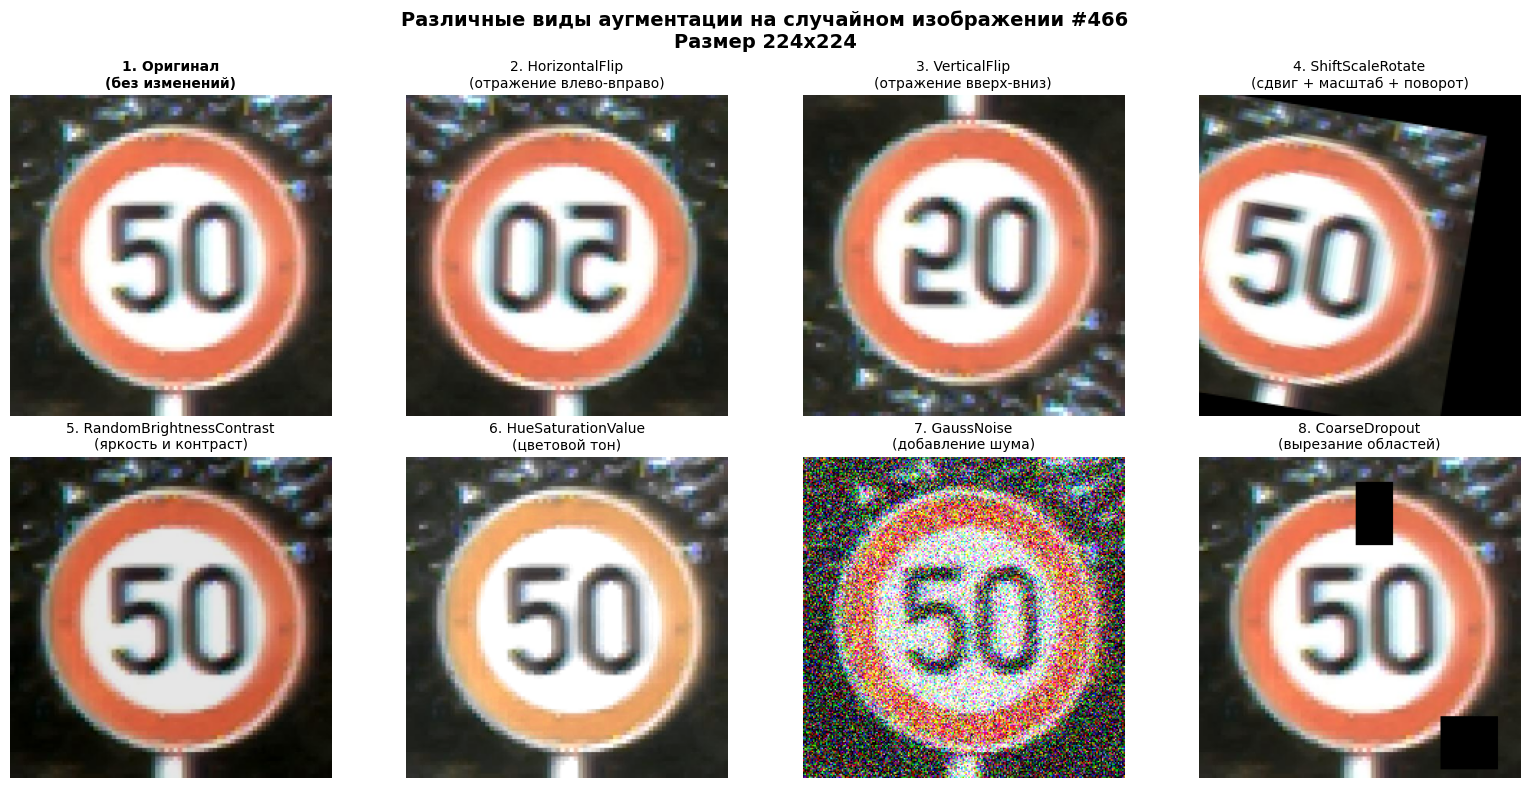


📊 Применяемые трансформации:
   • HorizontalFlip - зеркальное отражение по горизонтали
   • VerticalFlip - зеркальное отражение по вертикали
   • ShiftScaleRotate - сдвиг, масштабирование и поворот
   • RandomBrightnessContrast - изменение яркости и контраста
   • HueSaturationValue - изменение цветовой гаммы
   • GaussNoise - добавление случайного шума
   • CoarseDropout - случайное вырезание прямоугольных областей
✅ Визуализация завершена!


In [ ]:

def show_augmentation_examples(images_data):
    """Показывает примеры разных аугментаций на случайном изображении"""
    
    if len(images_data) == 0:
        print("❌ Нет данных для визуализации!")
        return
    
    # Выбираем случайное изображение
    random_idx = np.random.randint(0, len(images_data))
    
    # ⭐ ВАЖНО: правильное преобразование из float32 [0-1] в uint8 [0-255]
    original_image = images_data[random_idx]
    
    # Проверяем диапазон значений
    print(f"Диапазон значений изображения: min={original_image.min():.3f}, max={original_image.max():.3f}")
    
    # Конвертируем в uint8 для отображения
    if original_image.max() <= 1.0:
        original_image_uint8 = (original_image * 255).astype(np.uint8)
    else:
        original_image_uint8 = original_image.astype(np.uint8)
    
    print(f"✅ Показываю аугментацию для изображения #{random_idx}")
    
    # Создаем 8 разных аугментаций с понятными названиями
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # 1. Оригинал
    axes[0].imshow(original_image_uint8)
    axes[0].set_title("1. Оригинал\n(без изменений)", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # 2. Horizontal Flip
    aug = albu.HorizontalFlip(p=1.0)
    result = aug(image=original_image_uint8)
    axes[1].imshow(result['image'])
    axes[1].set_title("2. HorizontalFlip\n(отражение влево-вправо)", fontsize=10)
    axes[1].axis('off')
    
    # 3. Vertical Flip
    aug = albu.VerticalFlip(p=1.0)
    result = aug(image=original_image_uint8)
    axes[2].imshow(result['image'])
    axes[2].set_title("3. VerticalFlip\n(отражение вверх-вниз)", fontsize=10)
    axes[2].axis('off')
    
    # 4. ShiftScaleRotate
    aug = albu.ShiftScaleRotate(
        shift_limit=0.2, 
        scale_limit=0.2, 
        rotate_limit=30, 
        p=1.0
    )
    result = aug(image=original_image_uint8)
    axes[3].imshow(result['image'])
    axes[3].set_title("4. ShiftScaleRotate\n(сдвиг + масштаб + поворот)", fontsize=10)
    axes[3].axis('off')
    
    # 5. Brightness + Contrast
    aug = albu.RandomBrightnessContrast(
        brightness_limit=0.3, 
        contrast_limit=0.3, 
        p=1.0
    )
    result = aug(image=original_image_uint8)
    axes[4].imshow(result['image'])
    axes[4].set_title("5. RandomBrightnessContrast\n(яркость и контраст)", fontsize=10)
    axes[4].axis('off')
    
    # 6. Hue + Saturation
    aug = albu.HueSaturationValue(
        hue_shift_limit=20, 
        sat_shift_limit=30, 
        val_shift_limit=20, 
        p=1.0
    )
    result = aug(image=original_image_uint8)
    axes[5].imshow(result['image'])
    axes[5].set_title("6. HueSaturationValue\n(цветовой тон)", fontsize=10)
    axes[5].axis('off')
    
    # 7. Gauss Noise
    aug = albu.GaussNoise(var_limit=(10, 50), p=1.0)
    result = aug(image=original_image_uint8)
    axes[6].imshow(result['image'])
    axes[6].set_title("7. GaussNoise\n(добавление шума)", fontsize=10)
    axes[6].axis('off')
    
    # 8. Coarse Dropout
    aug = albu.CoarseDropout(
        max_holes=6, 
        max_height=16, 
        max_width=16, 
        fill_value=0, 
        p=1.0
    )
    result = aug(image=original_image_uint8)
    axes[7].imshow(result['image'])
    axes[7].set_title("8. CoarseDropout\n(вырезание областей)", fontsize=10)
    axes[7].axis('off')
    
    plt.suptitle(f'Различные виды аугментации на случайном изображении #{random_idx}\nРазмер {INFER_WIDTH}x{INFER_HEIGHT}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Применяемые трансформации:")
    print("   • HorizontalFlip - зеркальное отражение по горизонтали")
    print("   • VerticalFlip - зеркальное отражение по вертикали")
    print("   • ShiftScaleRotate - сдвиг, масштабирование и поворот")
    print("   • RandomBrightnessContrast - изменение яркости и контраста")
    print("   • HueSaturationValue - изменение цветовой гаммы")
    print("   • GaussNoise - добавление случайного шума")
    print("   • CoarseDropout - случайное вырезание прямоугольных областей")
    print("✅ Визуализация завершена!")


# ==================== ВЫЗОВ ====================
print("\n" + "="*50)
print(" ВИЗУАЛИЗАЦИЯ АУГМЕНТАЦИИ")
print("="*50)

show_augmentation_examples(X)

# ПОДГОТОВКА

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)
X = X.astype('float32') / 255.0

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

NUM_CLASSES = len(np.unique(y_train))

print(f"\nTrain: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Classes: {NUM_CLASSES}")

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

#  ВЕСА КЛАССОВ (УСИЛЕННЫЕ)

In [ ]:

class_weight = {}
total = len(y_train)
print("\n" + "="*50)
print("ВЕСА КЛАССОВ")
print("="*50)

for i in range(NUM_CLASSES):
    count = np.sum(y_train == i)
    if count < 10:
        weight = 7.0
    elif count < 20:
        weight = 5.0
    elif count < 50:
        weight = 3.0
    elif count < 100:
        weight = 2.0
    elif count < 200:
        weight = 1.5
    else:
        weight = 1.0
    
    class_weight[i] = weight
    class_name = label_encoder.classes_[i] if i < len(label_encoder.classes_) else str(i)
    print(f"  {class_name[:25]:25s}: {count:4d} → вес = {weight:.1f}")

# МОДЕЛЬ (EFFICIENTNETB0 + 224x224)

In [ ]:

def build_model(input_shape=(224, 224, 3), num_classes=15):
    base = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
    x = base(x, training=False)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    # Усиленный классификатор
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs), base

# ==================== СОЗДАНИЕ МОДЕЛИ ====================
print("\n" + "="*50)
print("СОЗДАНИЕ МОДЕЛИ (224x224, EfficientNetB0)")
print("="*50)

model, base_model = build_model((INFER_HEIGHT, INFER_WIDTH, 3), NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ГЕНЕРАТОРЫ

In [ ]:

train_gen = DataGenerator(X_train, y_train_cat, batch_size=BATCH_SIZE, augment=True)
val_gen = DataGenerator(X_val, y_val_cat, batch_size=BATCH_SIZE, augment=False)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_phase1.h5', monitor='val_accuracy', save_best_only=True, verbose=1, mode='max')
]

# ФАЗА 1: ОБУЧЕНИЕ КЛАССИФИКАТОРА

In [ ]:


# ==================== ФАЗА 1: ОБУЧЕНИЕ КЛАССИФИКАТОРА ====================
print("\n" + "="*50)
print("ФАЗА 1: ОБУЧЕНИЕ КЛАССИФИКАТОРА")
print("="*50)

start = time.time()
history1 = model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)
print(f"⏱️ Время фазы 1: {(time.time() - start)/60:.1f} мин")

# ФАЗА 2: ТОНКАЯ НАСТРОЙКА

In [ ]:

print("\n" + "="*50)
print("ФАЗА 2: ТОНКАЯ НАСТРОЙКА")
print("="*50)

base_model.trainable = True

# Замораживаем первые 100 слоёв
for i, layer in enumerate(base_model.layers):
    if i < 100:
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model_phase2.h5', monitor='val_accuracy', save_best_only=True, verbose=1, mode='max')
]

start2 = time.time()
history2 = model.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks2,
    verbose=1
)
print(f"⏱️ Время фазы 2: {(time.time() - start2)/60:.1f} мин")
print(f"⏱️ ОБЩЕЕ ВРЕМЯ: {(time.time() - start)/60:.1f} мин")

# ОЦЕНКА 

In [ ]:

model.load_weights('best_model_phase2.h5')
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)

print("\n" + "="*50)
print(f" ИТОГОВАЯ ТОЧНОСТЬ: {test_acc:.2%}")
print("="*50)

pred = model.predict(X_test)
pred_class = np.argmax(pred, axis=1)

precision = precision_score(y_test, pred_class, average='weighted', zero_division=0)
recall = recall_score(y_test, pred_class, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred_class, average='weighted', zero_division=0)

print(f"\n Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-Score: {f1:.4f}")

print("\n=== ОТЧЕТ ПО КЛАССАМ ===")
print(classification_report(y_test, pred_class, target_names=label_encoder.classes_, zero_division=0))

# ГРАФИКИ

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Фаза 1
axes[0, 0].plot(history1.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history1.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Phase 1: Loss', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history1.history['accuracy'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history1.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[0, 1].set_title('Phase 1: Accuracy', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True)

# Фаза 2
axes[1, 0].plot(history2.history['loss'], label='Train Loss', linewidth=2)
axes[1, 0].plot(history2.history['val_loss'], label='Val Loss', linewidth=2)
axes[1, 0].set_title('Phase 2: Loss (Fine-tuning)', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(history2.history['accuracy'], label='Train Acc', linewidth=2)
axes[1, 1].plot(history2.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1, 1].set_title('Phase 2: Accuracy (Fine-tuning)', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# МАТРИЦА ОШИБОК

In [ ]:

plt.figure(figsize=(20, 18))
cm = confusion_matrix(y_test, pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix (224x224, EfficientNetB0) - Accuracy: {test_acc:.2%}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# СОХРАНЕНИЕ


In [ ]:

model.save('final_model_224x224.h5')
with open('label_encoder_224.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"\n Модель сохранена как 'final_model_224x224.h5'")
print("="*50)
print(f" ИТОГ: {test_acc:.2%}")
print("="*50)

# ПРОВЕРКА НА ТЕСТОВЫХ ДАННЫХ

In [ ]:

print("\n" + "="*70)
print(" РАСШИРЕННОЕ ТЕСТИРОВАНИЕ МОДЕЛИ")
print("="*70)

# 1. Базовые метрики
print(f"\n БАЗОВЫЕ МЕТРИКИ:")
print(f"   • Test Loss: {test_loss:.4f}")
print(f"   • Test Accuracy: {test_acc:.4f} ({test_acc:.2%})")

# 2. Детальный отчет по каждому классу
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Weighted метрики (учитывают дисбаланс классов)
precision_weighted = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

# Macro метрики (каждый класс имеет равный вес)
precision_macro = precision_score(y_test, y_pred_classes, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred_classes, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)

print(f"\n📈 ВЗВЕШЕННЫЕ МЕТРИКИ (учитывают частоту классов):")
print(f"   • Weighted Precision: {precision_weighted:.4f}")
print(f"   • Weighted Recall: {recall_weighted:.4f}")
print(f"   • Weighted F1-Score: {f1_weighted:.4f}")

print(f"\n СРЕДНИЕ МЕТРИКИ (каждый класс имеет равный вес):")
print(f"   • Macro Precision: {precision_macro:.4f}")
print(f"   • Macro Recall: {recall_macro:.4f}")
print(f"   • Macro F1-Score: {f1_macro:.4f}")

# 3. Детальный отчет по каждому классу
print(f"\n ПОДРОБНЫЙ ОТЧЕТ ПО КАЖДОМУ КЛАССУ:")
print("-" * 70)
print(classification_report(y_test, y_pred_classes, 
                           target_names=label_encoder.classes_, 
                           zero_division=0))

# 4. Анализ ошибок (топ-5 самых частых ошибок)
print(f"\n АНАЛИЗ ОШИБОК (Топ-5 самых частых неверных предсказаний):")
print("-" * 70)

cm = confusion_matrix(y_test, y_pred_classes)
errors = []
for true_class in range(NUM_CLASSES):
    for pred_class in range(NUM_CLASSES):
        if true_class != pred_class and cm[true_class, pred_class] > 0:
            errors.append({
                'true': label_encoder.classes_[true_class],
                'pred': label_encoder.classes_[pred_class],
                'count': cm[true_class, pred_class]
            })

errors.sort(key=lambda x: x['count'], reverse=True)
for i, err in enumerate(errors[:5]):
    print(f"   {i+1}. {err['true']} → {err['pred']}: {err['count']} ошибок")

# 5. Точность по каждому классу (от лучшего к худшему)
print(f"\n ТОЧНОСТЬ ПО КАЖДОМУ КЛАССУ (от лучшего к худшему):")
print("-" * 70)

class_accuracies = []
for i in range(NUM_CLASSES):
    mask = (y_test == i)
    if mask.sum() > 0:
        acc = np.sum(y_pred_classes[mask] == i) / mask.sum()
        class_accuracies.append({
            'class': label_encoder.classes_[i],
            'accuracy': acc,
            'samples': mask.sum()
        })

class_accuracies.sort(key=lambda x: x['accuracy'], reverse=True)
for i, ca in enumerate(class_accuracies):
    status = "" if ca['accuracy'] > 0.7 else "⚠️" if ca['accuracy'] > 0.5 else "❌"
    print(f"   {i+1}. {status} {ca['class'][:30]:30s}: {ca['accuracy']:.2%} ({ca['samples']} примеров)")

# 6. Анализ уверенности модели
print(f"\n🎲 АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ:")
print("-" * 70)

confidences = np.max(y_pred, axis=1)
print(f"   • Средняя уверенность: {np.mean(confidences):.2%}")
print(f"   • Медианная уверенность: {np.median(confidences):.2%}")
print(f"   • Минимальная уверенность: {np.min(confidences):.2%}")
print(f"   • Максимальная уверенность: {np.max(confidences):.2%}")

# Уверенность для правильных и неправильных предсказаний
correct_mask = (y_pred_classes == y_test)
wrong_mask = (y_pred_classes != y_test)

if np.any(correct_mask):
    print(f"   • Средняя уверенность при ПРАВИЛЬНЫХ ответах: {np.mean(confidences[correct_mask]):.2%}")
if np.any(wrong_mask):
    print(f"   • Средняя уверенность при НЕПРАВИЛЬНЫХ ответах: {np.mean(confidences[wrong_mask]):.2%}")

# ==================== ПОКАЗ РАНДОМНЫХ ФОТО ИЗ ТЕСТОВОЙ ВЫБОРКИ ====================
print(f"\n РАНДОМНЫЕ ФОТО ИЗ ТЕСТОВОЙ ВЫБОРКИ (с предсказаниями):")
print("-" * 70)

# Выбираем 8 случайных индексов из тестовой выборки
np.random.seed(42)  # Для воспроизводимости, можно убрать
num_samples = min(8, len(X_test))
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Создаем сетку 2x4 для отображения
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    # Изображение (нормализовано от 0 до 1, конвертируем в uint8)
    img_display = (X_test[idx] * 255).astype(np.uint8)
    
    true_class = label_encoder.classes_[y_test[idx]]
    pred_class = label_encoder.classes_[y_pred_classes[idx]]
    confidence = confidences[idx]
    
    # Определяем цвет заголовка: зеленый если правильно, красный если ошибка
    is_correct = (y_test[idx] == y_pred_classes[idx])
    title_color = 'green' if is_correct else 'red'
    status = "✓" if is_correct else "✗"
    
    # Отображаем изображение
    axes[i].imshow(img_display)
    axes[i].set_title(f"{status} True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1%}", 
                     fontsize=10, color=title_color, fontweight='bold')
    axes[i].axis('off')
    
    # Добавляем рамку: зеленую для правильных, красную для ошибочных
    for spine in axes[i].spines.values():
        spine.set_edgecolor(title_color)
        spine.set_linewidth(2)
        spine.set_visible(True)

# Скрываем лишние подграфики (если меньше 8 изображений)
for i in range(len(random_indices), len(axes)):
    axes[i].axis('off')

plt.suptitle(f"Случайные изображения из тестовой выборки\nТочность модели: {test_acc:.2%}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Статистика по показанным изображениям
correct_in_sample = sum(1 for idx in random_indices if y_test[idx] == y_pred_classes[idx])
print(f"\n Статистика по показанным {num_samples} изображениям:")
print(f"   • Правильно предсказано: {correct_in_sample}/{num_samples} ({correct_in_sample/num_samples:.0%})")
print(f"   • Неправильно: {num_samples - correct_in_sample}/{num_samples} ({(num_samples-correct_in_sample)/num_samples:.0%})")

# ==================== ПОКАЗ УВЕРЕННЫХ И НЕУВЕРЕННЫХ ПРЕДСКАЗАНИЙ ====================
print(f"\n ПРИМЕРЫ САМЫХ УВЕРЕННЫХ И НЕУВЕРЕННЫХ ПРЕДСКАЗАНИЙ:")
print("-" * 70)

# Самые уверенные предсказания (правильные)
correct_preds = [(i, confidences[i]) for i in range(len(y_test)) if y_pred_classes[i] == y_test[i]]
if correct_preds:
    correct_preds.sort(key=lambda x: x[1], reverse=True)
    top_confident = correct_preds[:2]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    for i, (idx, conf) in enumerate(top_confident):
        img_display = (X_test[idx] * 255).astype(np.uint8)
        true_class = label_encoder.classes_[y_test[idx]]
        
        axes[i].imshow(img_display)
        axes[i].set_title(f"Самый уверенный #{i+1}\nКласс: {true_class}\nУверенность: {conf:.1%}", 
                         fontsize=10, color='green', fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle("Примеры самых уверенных предсказаний модели", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Самые неуверенные предсказания (правильные)
low_conf_correct = [(i, confidences[i]) for i in range(len(y_test)) 
                    if y_pred_classes[i] == y_test[i] and confidences[i] < 0.7]
if low_conf_correct:
    low_conf_correct.sort(key=lambda x: x[1])
    top_low_confident = low_conf_correct[:2]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    for i, (idx, conf) in enumerate(top_low_confident):
        img_display = (X_test[idx] * 255).astype(np.uint8)
        true_class = label_encoder.classes_[y_test[idx]]
        
        axes[i].imshow(img_display)
        axes[i].set_title(f"Неуверенный правильный #{i+1}\nКласс: {true_class}\nУверенность: {conf:.1%}", 
                         fontsize=10, color='orange', fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle("Примеры правильных, но неуверенных предсказаний", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 7. Итоговая оценка
print("\n" + "="*70)
print(" ИТОГОВАЯ ОЦЕНКА МОДЕЛИ")
print("="*70)

if test_acc >= 0.9:
    grade = " ОТЛИЧНО"
    comment = "Модель показывает высокую точность!"
elif test_acc >= 0.8:
    grade = " ХОРОШО"
    comment = "Модель показывает хорошие результаты."
elif test_acc >= 0.7:
    grade = " СРЕДНЕ"
    comment = "Модель можно улучшить."
else:
    grade = " НУЖНО УЛУЧШИТЬ"
    comment = "Рекомендуется добавить данных или увеличить эпохи."

print(f"   {grade}")
print(f"   {comment}")
print(f"   • Итоговая точность: {test_acc:.2%}")
print(f"   • F1-Score (weighted): {f1_weighted:.4f}")
print("="*70)

# ВИЗУАЛИЗАЦИЯ МОДЕЛИ

In [ ]:


print("\n" + "="*50)
print(" КОМПАКТНАЯ СТРУКТУРА МОДЕЛИ")
print("="*50)

# Компактная версия (EfficientNetB0 отображается как один блок)
plot_model(
    model,
    to_file='model_compact.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=False,        # EfficientNetB0 как один блок
    dpi=50
)

display(Image('model_compact.png'))
print(" Компактная схема сохранена как 'model_compact.png'")